# Chapter 30: Digital Twins and Automation

This notebook demonstrates how to use NeqSim as a **digital twin** of a process
plant. We build a process model, then use the `ProcessAutomation` API to read
and write simulation variables by string address — the same way a plant control
system interacts with field instruments.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch21_digital_twins.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 30.1 Build a Process Model (Digital Twin)

We create a simple gas processing train: feed stream → separator → compressor → cooler.
This represents the *digital twin* — a simulation model that mirrors the physical plant.

In [2]:
# Define the feed fluid
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 30.0, 40.0)
fluid.addComponent("methane", 0.80)
fluid.addComponent("ethane", 0.10)
fluid.addComponent("propane", 0.05)
fluid.addComponent("n-heptane", 0.03)
fluid.addComponent("water", 0.02)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

# Build process
feed = jneqsim.process.equipment.stream.Stream("Feed Gas", fluid)
feed.setFlowRate(50000.0, "kg/hr")
feed.setTemperature(30.0, "C")
feed.setPressure(40.0, "bara")

separator = jneqsim.process.equipment.separator.Separator("Inlet Separator", feed)

compressor = jneqsim.process.equipment.compressor.Compressor("Export Compressor", separator.getGasOutStream())
compressor.setOutletPressure(100.0)

cooler = jneqsim.process.equipment.heatexchanger.Cooler("After Cooler", compressor.getOutletStream())
cooler.setOutTemperature(273.15 + 35.0)

process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(separator)
process.add(compressor)
process.add(cooler)
process.run()

print("Process model (digital twin) built and converged")
print(f"Compressor power: {compressor.getPower('kW'):.1f} kW")
print(f"Cooler outlet T: {cooler.getOutletStream().getTemperature('C'):.1f} C")

Process model (digital twin) built and converged
Compressor power: 1421.1 kW
Cooler outlet T: 35.0 C


## 30.2 ProcessAutomation: String-Addressable Variable Access

The `ProcessAutomation` API provides a flat, string-based interface for reading
and writing simulation variables — similar to an OPC server in a real plant.
This is the **preferred API for digital twin and agent applications**.

In [3]:
# Get the automation facade
auto = process.getAutomation()

# Discover available equipment units
units = list(auto.getUnitList())
print("=== Equipment Units ===")
for u in units:
    eq_type = auto.getEquipmentType(str(u))
    print(f"  {u} ({eq_type})")

# List variables for the compressor
print("\n=== Compressor Variables ===")
comp_vars = list(auto.getVariableList("Export Compressor"))
for v in comp_vars[:8]:  # show first 8
    print(f"  {v.getAddress()} [{v.getType()}] ({v.getDefaultUnit()}) - {v.getDescription()}")

=== Equipment Units ===
  Feed Gas (Stream)
  Inlet Separator (Separator)
  Export Compressor (Compressor)
  After Cooler (Cooler)

=== Compressor Variables ===
  Export Compressor.temperature [OUTPUT] (K) - Equipment temperature
  Export Compressor.pressure [OUTPUT] (bara) - Equipment pressure
  Export Compressor.outletPressure [INPUT] (bara) - Compressor outlet pressure
  Export Compressor.polytropicEfficiency [INPUT] () - Polytropic efficiency (fraction)
  Export Compressor.isentropicEfficiency [INPUT] () - Isentropic efficiency (fraction)
  Export Compressor.power [OUTPUT] (kW) - Compressor power consumption
  Export Compressor.speed [INPUT] (rpm) - Compressor speed
  Export Compressor.polytropicHead [OUTPUT] (kJ/kg) - Polytropic head


In [4]:
# Read key process variables using string addresses
variables_to_read = [
    ("Feed Gas.temperature", "C"),
    ("Feed Gas.pressure", "bara"),
    ("Feed Gas.flowRate", "kg/hr"),
    ("Export Compressor.power", "kW"),
    ("After Cooler.outletStream.temperature", "C"),
]

print("=== Simulated Process Values (Digital Twin) ===")
simulated_values = {}
for addr, unit in variables_to_read:
    try:
        val = auto.getVariableValue(addr, unit)
        simulated_values[addr] = val
        print(f"  {addr}: {val:.2f} {unit}")
    except Exception as e:
        print(f"  {addr}: Could not read - {e}")

=== Simulated Process Values (Digital Twin) ===
  Feed Gas.temperature: 30.00 C
  Feed Gas.pressure: 40.00 bara
  Feed Gas.flowRate: 50000.00 kg/hr
  Export Compressor.power: 1421.05 kW
  After Cooler.outletStream.temperature: 35.00 C


## 30.3 Simulated vs Measured: Digital Twin Comparison

In a real digital twin, "measured" values come from plant historian data (e.g.,
OSIsoft PI). Here we generate synthetic measured values with realistic noise
and compare them against the simulation.

In [5]:
# Simulated "measured" values from plant historian (synthetic)
np.random.seed(42)

tags = ["Feed Temperature", "Feed Pressure", "Feed Flow Rate", "Compressor Power", "Cooler Outlet T"]
units_list = ["C", "bara", "kg/hr", "kW", "C"]
sim_vals = [float(simulated_values[address]) for address, unit in variables_to_read]  # actual process predictions

# Add realistic measurement noise (1-3% of reading)
noise_pct = [0.02, 0.01, 0.03, 0.02, 0.02]
measured_vals = [sv * (1 + np.random.normal(0, npc) ) for sv, npc in zip(sim_vals, noise_pct)]

# Use actual simulated values where available
for i, (addr, unit) in enumerate(variables_to_read):
    if addr in simulated_values:
        sim_vals[i] = simulated_values[addr]
        measured_vals[i] = sim_vals[i] * (1 + np.random.normal(0, noise_pct[i]))

deviations = [(m - s) / s * 100 if s != 0 else 0 for m, s in zip(measured_vals, sim_vals)]

print(f"{'Tag':<22} {'Simulated':>12} {'Measured':>12} {'Dev [%]':>10}")
print("-" * 60)
for tag, sv, mv, dev, u in zip(tags, sim_vals, measured_vals, deviations, units_list):
    print(f"{tag:<22} {sv:>10.1f} {u}  {mv:>10.1f} {u}  {dev:>8.2f}%")

Tag                       Simulated     Measured    Dev [%]
------------------------------------------------------------
Feed Temperature             30.0 C        29.9 C     -0.47%
Feed Pressure                40.0 bara        40.6 bara      1.58%
Feed Flow Rate            50000.0 kg/hr     51151.2 kg/hr      2.30%
Compressor Power           1421.1 kW      1407.7 kW     -0.94%
Cooler Outlet T              35.0 C        35.4 C      1.09%


Figure saved to ../figures/ch21_digital_twin_comparison.png


ch21_digital_twins.ipynb:cell9:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


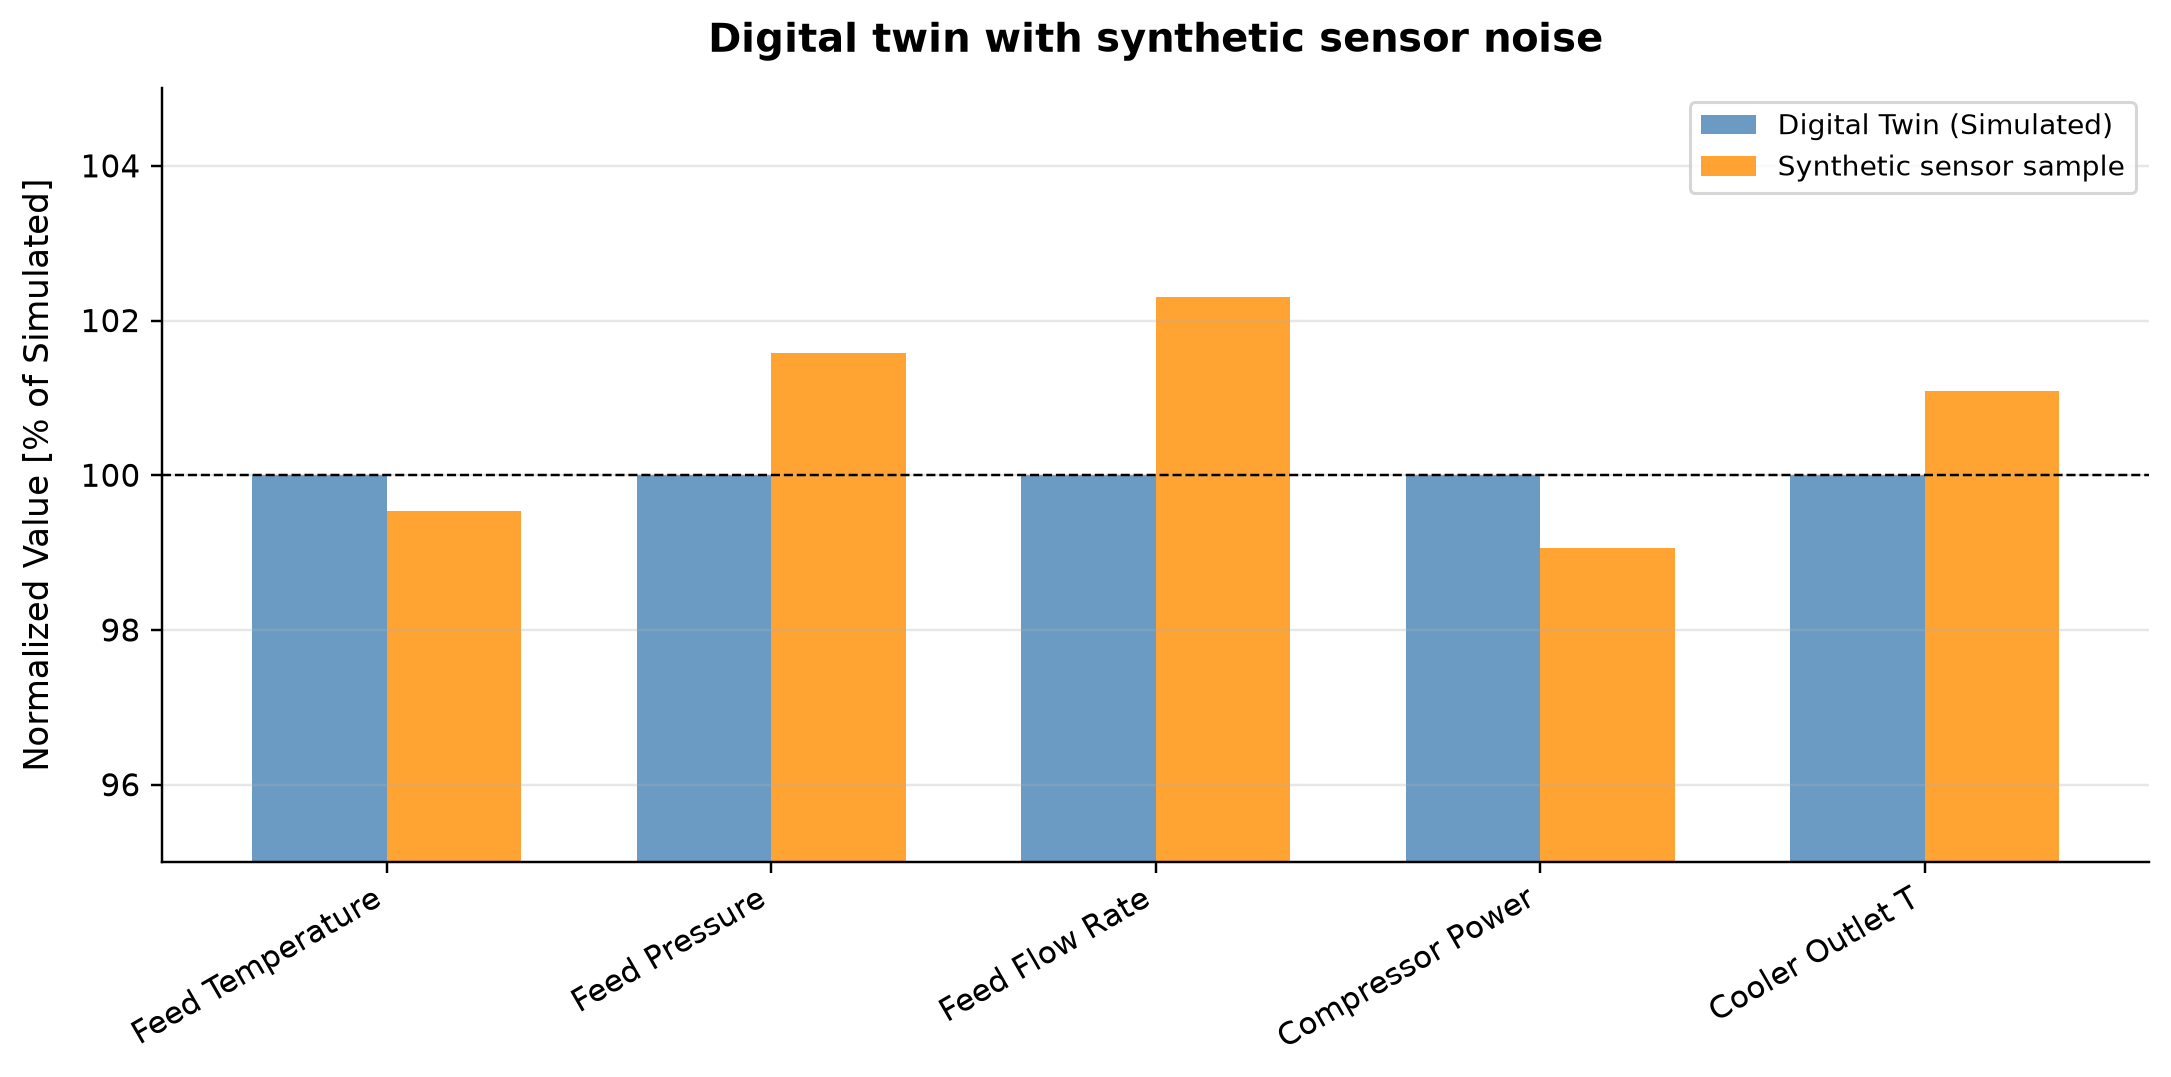

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(tags))
width = 0.35

# Normalize for comparison
sim_norm = [s / s * 100 for s in sim_vals]
meas_norm = [m / s * 100 for m, s in zip(measured_vals, sim_vals)]

bars1 = ax.bar(x - width/2, sim_norm, width, label='Digital Twin (Simulated)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, meas_norm, width, label='Synthetic sensor sample', color='darkorange', alpha=0.8)

ax.set_ylabel('Normalized Value [% of Simulated]')
ax.set_title('Digital twin with synthetic sensor noise')
ax.set_xticks(x)
ax.set_xticklabels(tags, rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(95, 105)
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch21_digital_twin_comparison.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch21_digital_twin_comparison.png")

**Executed-figure discussion.** Digital Twin (Simulated): normalized value remains 100 % of Simulated across the plotted cases. Synthetic sensor sample: normalized value spans 99.06–102.3 % of Simulated across the plotted cases.

ProcessAutomation supplies the simulated values; the comparison values are generated by adding stated synthetic sensor noise. The residuals illustrate monitoring logic and cannot establish agreement with an operating plant. Replace synthetic samples with aligned historian tags, units and measurement uncertainty.


## 30.4 Summary

**Key takeaways:**

1. **Digital twins** are simulation models that mirror a physical plant in real time.
2. The **ProcessAutomation** API provides OPC-like string-based variable access.
3. `getUnitList()` discovers equipment; `getVariableList()` discovers readable/writable variables.
4. Comparing simulated vs measured values identifies **model drift** or **instrument faults**.
5. Self-healing automation (`getVariableValueSafe()`) auto-corrects address typos and validates physical bounds.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                          Figure  Panel                   Series                     Output / unit  Minimum  Maximum  Finite points  Missing points
ch21_digital_twin_comparison.png      1                  Curve 1 Normalized Value [% of Simulated]      100      100              2               0
ch21_digital_twin_comparison.png      1 Digital Twin (Simulated) Normalized Value [% of Simulated]      100      100              5               0
ch21_digital_twin_comparison.png      1  Synthetic sensor sample Normalized Value [% of Simulated]  99.0611  102.302              5               0
